# 모듈 (1/5): 벡터 임베딩 (Embeddings)
## 지식(Memory & Knowledge) 시리즈의 기초편

---

이 노트북은 **모듈 3(지식)** 을 5개 주제로 나눈 첫 번째 편으로, RAG·Graph RAG·에이전트
메모리의 토대가 되는 **벡터 임베딩과 시맨틱 유사도** 를 다룹니다.

### 이 시리즈 구성
1. **`M04_1_embeddings.ipynb`** ← (현재) 임베딩 · 시맨틱 유사도 · 공급자 비교
2. `M04_2_vector_rag.ipynb` — 문서 전처리 · 벡터 DB 3종 · LangChain RAG
3. `M04_3_graph_rag.ipynb` — 지식 그래프 · Neo4j · LlamaIndex GraphRAG
4. `M04_4_agent_memory.ipynb` — 에이전트 메모리 **직접 구현** · Deep-Knowledge Agent
5. `M04_5_memory.ipynb` — LangGraph **메모리 인프라**(체크포인터 · Store · 영속화)

### 학습 목표
1. 벡터 임베딩의 개념과 코사인 유사도 이해
2. **오프라인** 임베딩 모델(`sentence-transformers`) 사용 — 로드 가능한 모델 카탈로그 + 2종 비교
3. **온라인 무료** 임베딩 API 사용 — Google(Gemini) · NVIDIA build · OpenRouter
   (같은 문장으로 공급자별 상호 유사도 매트릭스 비교)
4. 오프라인 ↔ 온라인 **성능 비교**(차원 · 속도 · 검색 품질 Top-1/Top-3/MRR)
5. 검색 품질 지표(Top-1 · Top-3 · MRR)의 의미와 해석

> 임베딩을 **Neo4j 벡터 인덱스**에 저장해 검색하는 실습은 그래프가 주제인
> [3편 `M04_3_graph_rag.ipynb`](M04_3_graph_rag.ipynb) 에서 다룹니다.

> 📦 **환경 설치·실행 명령**은 [`env_guides/M04_1_embeddings.md`](env_guides/M04_1_embeddings.md) 참고.
> 임베딩 공급자 추상화는 [`agentic_lib/embeddings.py`](agentic_lib/embeddings.py) 로 분리해 import 합니다.

### 이 노트북의 전체 흐름

```
              [ 텍스트 ]
                  │
      ┌───────────┴────────────┐
      │                        │
[오프라인 임베딩]         [온라인 임베딩 API]
sentence-transformers     google / nvidia / openrouter
(무료·오프라인·빠름)        (무료 티어·고차원·고품질)
      │                        │
      └───────────┬────────────┘
                  ↓
          [ 코사인 유사도 ]
                  ↓
                  ↓
     [성능 비교: 속도 / 차원 / 검색 품질]
                  ↓
        [의미 공간 시각화로 최종 비교]
```

**핵심 아이디어**: 임베딩은 *교체 가능한 부품* 입니다. LLM 을 `utils.get_llm()` 하나로
갈아끼우듯, 임베딩도 `embeddings.get_embedder()` 하나로 오프라인 ↔ 온라인을 바꿉니다.
바꿔 끼우고 **같은 데이터로 측정** 해서 고르는 것이 이 노트북의 목표입니다.

---
## 1. 패키지 설치 및 공급자

### 1-1. LLM 공급자
LLM 은 `.env` 의 `LLM_PROVIDER` 를 그대로 사용합니다(`utils.get_llm()`). 이 노트북은
임베딩이 주제라 LLM 은 거의 쓰지 않으므로, 어떤 공급자든 상관없습니다.

### 1-2. 임베딩 공급자 (이 노트북의 주제)

| # | 공급자 | `EMBED_PROVIDER` | 무료 | 기본 모델 | 차원 | 비고 |
|---|--------|------------------|------|-----------|------|------|
| 1 | **로컬 (오프라인)** ⭐기본 | `local` | ✅ | `paraphrase-multilingual-MiniLM-L12-v2` | 384 | 최초 1회 다운로드 후 네트워크 불필요 |
| 2 | **Google AI Studio** | `google` | ✅ 무료 티어 | `gemini-embedding-001` | 768~3072 | `taskType`·차원 조절 지원 |
| 3 | **NVIDIA build** | `nvidia` | ✅ 무료 크레딧 | `nvidia/nemotron-3-embed-1b` | 2048 | `input_type`(query/passage) 필수 |
| 4 | **OpenRouter** | `openrouter` | ✅ `:free` 모델 | `nvidia/llama-nemotron-embed-vl-1b-v2:free` | 2048 | OpenAI 호환, 여러 공급자 라우팅 |
| 5 | Ollama (로컬 서버) | `ollama` | ✅ | `bge-m3` | 1024 | `ollama pull bge-m3` 필요 |

> 온라인 3종은 **모두 무료로 사용 가능** 하며, `.env` 에 해당 키만 있으면 됩니다
> (`GOOGLE_API_KEY` / `NVIDIA_API_KEY` / `OPENROUTER_API_KEY`).
> 키가 없는 공급자는 자동으로 건너뛰므로, **하나만 있어도** 실습이 진행됩니다.

### 필요 패키지 (CMD)
```bat
uv pip install sentence-transformers numpy requests
REM 비교 그래프·의미 공간 시각화(PCA)
uv pip install matplotlib scikit-learn
```

> 자세한 설치·키 발급·문제해결: [`env_guides/M04_1_embeddings.md`](env_guides/M04_1_embeddings.md)

In [8]:
# 자기완결 setup: 이 노트북만 단독 실행해도 되도록 공통 셋업을 맨 앞에 둔다
import sys, os
sys.path.insert(0, os.path.abspath(''))  # notebooks/ 를 import 경로에 추가

import utils
utils.reload_env()  # .env 재로드 (LLM_PROVIDER 등 갱신) + 현재 공급자 상태 출력

from utils import (
    uv_install, get_llm, test_llm_connection,
    LLM_PROVIDER, chunk_text, cosine_similarity,
)
# 공통 라이브러리: bootstrap(응답 정규화) / embeddings(임베딩 공급자 추상화)
from agentic_lib import bootstrap, embeddings as emb
from agentic_lib.bootstrap import to_text  # 공급자 무관 응답 정규화(<think> 제거 포함)

# 이 노트북에 필요한 패키지만 보강 설치 (이미 있으면 건너뜀)
uv_install(['sentence-transformers', 'numpy', 'requests',
            'scikit-learn', 'matplotlib'])

llm = test_llm_connection()  # 공급자 무관 — None 이면 각 구현이 폴백 경로로 동작

LLM 공급자: openrouter
  OpenRouter Key: 설정됨  /  Model: nvidia/nemotron-3-super-120b-a12b:free
[uv] 설치 완료: ['sentence-transformers', 'numpy', 'requests', 'scikit-learn', 'matplotlib']
LLM 연결 성공 [openrouter]: 1 + 1을 계산하면 결과는 **2**입니다.  
기본적인 덧셈 연산으로, 1과 1을 더하면 2가 됩니다.


---
## 2. 벡터 임베딩 이해 (오프라인 모델)

텍스트를 고차원 숫자 벡터로 변환하면, **의미의 가까움을 숫자로 잴 수 있습니다.**
척도는 두 벡터가 이루는 각도인 **코사인 유사도**(1에 가까울수록 비슷함)입니다.

$$\text{cos\_sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

먼저 **오프라인** 모델(`sentence-transformers`)로 시작합니다. 최초 1회만 모델을
내려받고, 그 뒤로는 네트워크 없이 무료로 무제한 사용할 수 있습니다.

> 🔎 **이 절에서 쓰는 모델**: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
> — 384차원, 118M 파라미터, 50개 언어 지원(한국어 포함). 본 강의의 기본 오프라인 모델입니다.
> 다른 모델로 바꾸려면 `emb.get_embedder("local", model="<모델 이름>")` 한 줄만 고치면 됩니다.

In [9]:
# 오프라인 임베딩 모델(sentence-transformers): 최초 1회만 다운로드, 이후 네트워크 불필요
# get_embedder("local") 은 SentenceTransformer 를 감싼 LocalEmbedder 를 돌려준다.
import numpy as np

# 이 실습에서 쓸 모델을 코드에 명시한다(무엇을 쓰는지 항상 눈에 보이게)
LOCAL_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print(f"임베딩 모델 로딩: {LOCAL_MODEL}")
print("  (처음 실행 시 약 470MB 다운로드 — 이후 캐시되어 오프라인 동작)")
local_embedder = emb.get_embedder("local", model=LOCAL_MODEL)
print(f"\n로딩 완료")
print(f"  모델      : {local_embedder.model}")
print(f"  차원      : {local_embedder.dim}")
print(f"  실행 위치 : {'로컬(오프라인)' if not local_embedder.online else '원격 API'}")
print(f"  캐시 경로 : %USERPROFILE%\\.cache\\huggingface")

# 임베딩 테스트: 의미가 비슷한 문장일수록 코사인 유사도가 높게 나오는지 확인
sentences = [
    "인공지능 에이전트는 자율적으로 작업을 수행합니다",
    "AI 에이전트는 독립적으로 업무를 처리합니다",
    "오늘 날씨가 맑고 따뜻합니다",
    "LangGraph는 에이전트 워크플로우 프레임워크입니다",
]

# encode() 는 (문장 수, 차원) 배열을 돌려준다(기본적으로 L2 정규화되어 있음)
sentence_vecs = local_embedder.encode(sentences)
print(f"\n임베딩 배열 shape: {sentence_vecs.shape}")
print(f"첫 문장 벡터 앞 5개 값: {np.round(sentence_vecs[0][:5], 4)}")

# --- 전체 유사도 매트릭스 ---------------------------------------------------
sim_matrix = emb.cosine_sim_matrix(sentence_vecs, sentence_vecs)

print("\n=== 문장 간 유사도 매트릭스 ===")
print("      " + "".join(f"  S{j}   " for j in range(len(sentences))))
for i, row in enumerate(sim_matrix):
    print(f"  S{i} " + "".join(f"{v:7.3f}" for v in row))
for i, s in enumerate(sentences):
    print(f"  S{i}: {s}")

# --- 쿼리 기준 순위 ---------------------------------------------------------
query = sentences[0]
print(f"\n쿼리: '{query}'")
print("유사도 순위:")
for score, idx, sent in emb.rank_by_similarity(sentence_vecs[0], sentence_vecs,
                                               sentences, top_k=len(sentences)):
    if idx == 0:
        continue  # 자기 자신은 제외
    print(f"  [{score:.3f}] {sent}")

# utils.cosine_similarity(순수 파이썬 구현)로 같은 값이 나오는지 교차 검증
manual = cosine_similarity(sentence_vecs[0].tolist(), sentence_vecs[1].tolist())
print(f"\n검증) utils.cosine_similarity(S0, S1) = {manual:.3f} "
      f"/ 매트릭스 값 = {sim_matrix[0][1]:.3f}")

임베딩 모델 로딩: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  (처음 실행 시 약 470MB 다운로드 — 이후 캐시되어 오프라인 동작)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


로딩 완료
  모델      : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  차원      : 384
  실행 위치 : 로컬(오프라인)
  캐시 경로 : %USERPROFILE%\.cache\huggingface

임베딩 배열 shape: (4, 384)
첫 문장 벡터 앞 5개 값: [-0.0406 -0.0525 -0.0621 -0.0646 -0.0268]

=== 문장 간 유사도 매트릭스 ===
        S0     S1     S2     S3   
  S0   1.000  0.912  0.016  0.584
  S1   0.912  1.000 -0.071  0.497
  S2   0.016 -0.071  1.000  0.144
  S3   0.584  0.497  0.144  1.000
  S0: 인공지능 에이전트는 자율적으로 작업을 수행합니다
  S1: AI 에이전트는 독립적으로 업무를 처리합니다
  S2: 오늘 날씨가 맑고 따뜻합니다
  S3: LangGraph는 에이전트 워크플로우 프레임워크입니다

쿼리: '인공지능 에이전트는 자율적으로 작업을 수행합니다'
유사도 순위:
  [0.912] AI 에이전트는 독립적으로 업무를 처리합니다
  [0.584] LangGraph는 에이전트 워크플로우 프레임워크입니다
  [0.016] 오늘 날씨가 맑고 따뜻합니다

검증) utils.cosine_similarity(S0, S1) = 0.912 / 매트릭스 값 = 0.912


### 2-1. SentenceTransformer 로 로드할 수 있는 모델들

`SentenceTransformer("<모델 이름>")` 에 넣을 수 있는 모델은 HuggingFace Hub 에 수천 개가 있고,
**모델 이름만 바꾸면** 그대로 교체됩니다. 처음 고를 때 봐야 할 것은 네 가지입니다.

| 기준 | 왜 중요한가 |
|---|---|
| **언어** | 한국어 실습에서 가장 중요. 영어 전용 모델을 쓰면 유사도가 무의미해집니다 |
| **차원** | 저장·검색 비용에 직결(384 vs 1024는 저장 용량 2.7배 차이) |
| **파라미터 수** | 클수록 정확하지만 느리고 메모리를 더 씁니다 |
| **최대 토큰** | 512 토큰이 보통. 긴 문서를 통째로 넣으려면 8192 짜리(bge-m3 계열)가 필요 |

> ⚠️ 가장 유명한 `all-MiniLM-L6-v2` 는 **영어 전용** 입니다. 한국어를 넣으면
> 문장이 달라도 비슷한 벡터가 나와 유사도가 전부 뭉개집니다. 반드시 다국어/한국어 모델을 쓰세요.
> `intfloat/multilingual-e5-*` 계열은 입력에 `"query: "` / `"passage: "` 접두사를 붙여야
> 제 성능이 나오는 특이 규칙이 있습니다.

In [10]:
# SentenceTransformer 로 바로 쓸 수 있는 대표 모델 목록(라이브러리 내장 카탈로그)
emb.print_local_catalog()

# HuggingFace Hub 에서 직접 찾아볼 수도 있다(네트워크 필요, 실패해도 무시)
print("\n=== HF Hub 인기 sentence-transformers 모델 (다운로드 순) ===")
for model_id, downloads in emb.list_hub_models(limit=5):
    print(f"  {downloads:>12,}  {model_id}")

print("\n=== HF Hub 'korean' 검색 결과 ===")
for model_id, downloads in emb.list_hub_models(search="korean", limit=5):
    print(f"  {downloads:>12,}  {model_id}")

모델                                                            차원     파라미터     최대토큰  언어             비고
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
sentence-transformers/all-MiniLM-L6-v2                       384      23M      512  영어 전용          세계에서 가장 많이 쓰이는 임베딩. 가볍지만 한국어는 사실상 불가
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2   384     118M      512  다국어 50+        ⭐ 본 강의 기본값 — 한국어 가능 + 가장 빠름
sentence-transformers/paraphrase-multilingual-mpnet-base-v2   768     278M      512  다국어 50+        위 모델의 상위판 — 더 정확하지만 2~3배 느림
intfloat/multilingual-e5-small                               384     118M      512  다국어 100+       검색 특화. 입력에 'query: '/'passage: ' 접두사를 꼭 붙여야 함
intfloat/multilingual-e5-base                                768     278M      512  다국어 100+       e5-small 상위판. 접두사 규칙 동일
jhgan/ko-sroberta-multitask                                  768     111

### 2-2. 오프라인 모델 2개 비교 — 다국어 vs 한국어 특화

같은 오프라인이라도 모델 선택에 따라 결과가 크게 달라집니다. 성격이 다른 두 모델을 비교합니다.

| | A. `paraphrase-multilingual-MiniLM-L12-v2` | B. `jhgan/ko-sroberta-multitask` |
|---|---|---|
| 성격 | 다국어 50개 언어 범용 | **한국어 특화**(KLUE 기반) |
| 차원 | 384 | 768 |
| 파라미터 | 118M | 111M |
| 강점 | 가장 빠름, 언어 혼합 문서 | 한국어 뉘앙스 · 주제 구분 |

두 가지를 봅니다 — ① 같은 4문장의 **유사도 매트릭스**, ② 10개 문서 **검색 품질(MRR)과 속도**.

> 📥 B 모델은 최초 실행 시 약 440MB 를 내려받습니다(이후 캐시).

In [11]:
# 오프라인 모델 두 개를 나란히 비교한다 (A: 다국어 범용 / B: 한국어 특화)
print("모델 B 로딩... (최초 1회 다운로드, 약 440MB)")
local_ko = emb.get_embedder("local", model="jhgan/ko-sroberta-multitask")
print(f"로딩 완료: {local_ko.name} (차원 {local_ko.dim})\n")

local_pair = {"A. 다국어 범용": local_embedder, "B. 한국어 특화": local_ko}

# ① 같은 4문장에 대한 유사도 매트릭스
for label, embedder in local_pair.items():
    vecs = embedder.encode(sentences)
    matrix = emb.cosine_sim_matrix(vecs, vecs)
    emb.print_similarity_matrix(matrix, title=f"{label} — {embedder.name} ({embedder.dim}차원)")
    print()

# ② 검색 품질·속도 (10개 문서 / 10개 질문)
print("=== 검색 벤치마크 ===")
emb.print_benchmark_table(emb.benchmark(list(local_pair.values()), verbose=False))

모델 B 로딩... (최초 1회 다운로드, 약 440MB)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

로딩 완료: local:ko-sroberta-multitask (차원 768)

[A. 다국어 범용 — local:paraphrase-multilingual-MiniLM-L12-v2 (384차원)]
        S0     S1     S2     S3   
  S0   1.000  0.912  0.016  0.584
  S1   0.912  1.000 -0.071  0.497
  S2   0.016 -0.071  1.000  0.144
  S3   0.584  0.497  0.144  1.000

[B. 한국어 특화 — local:ko-sroberta-multitask (768차원)]
        S0     S1     S2     S3   
  S0   1.000  0.653  0.076  0.362
  S1   0.653  1.000  0.031  0.341
  S2   0.076  0.031  1.000  0.041
  S3   0.362  0.341  0.041  1.000

=== 검색 벤치마크 ===
임베더                                   차원 구분        색인(s)    질의(s)   Top-1   Top-3     MRR
--------------------------------------------------------------------------------------------
local:paraphrase-multilingual-MiniLM-L12-v2   384 오프라인       0.05    0.018   90.0%  100.0%   0.950
local:ko-sroberta-multitask          768 오프라인       0.08    0.026   90.0%  100.0%   0.950
--------------------------------------------------------------------------------------------
검색 품질 1위: loca

In [12]:
# 같은 문장 쌍을 두 모델이 어떻게 다르게 보는지 직접 비교
local_matrices = emb.similarity_matrices(local_pair.values(), sentences)
emb.print_pair_comparison(local_matrices, sentences)

문장 쌍   paraphrase-m ko-sroberta-
--------------------------------
S0–S1            0.912        0.653
S0–S2            0.016        0.076
S0–S3            0.584        0.362
S1–S2           -0.071        0.031
S1–S3            0.497        0.341
S2–S3            0.144        0.041
--------------------------------
기준(local:paraphrase-multilingual-MiniLM-L12-v2) 순위: S0–S1 > S0–S3 > S1–S3 > S2–S3 > S0–S2 > S1–S2
  △ 상위 3쌍까지 일치  local:ko-sroberta-multitask: S0–S1 > S0–S3 > S1–S3 > S0–S2 > S2–S3 > S1–S2

※ 절대값은 모델마다 스케일이 달라 그대로 비교하면 안 된다(어떤 모델은 0.9대, 어떤 모델은 0.3대에 몰린다).
※ 의미 있는 비교 기준은 '쌍의 순위' 와 '유사·비유사 간의 격차' 다.


### 2-3. 오프라인 모델의 query / passage 접두사

일부 검색 특화 모델은 **입력 앞에 역할 접두사를 붙이는 것을 전제로 학습** 되었습니다.
대표적으로 `intfloat/multilingual-e5-*` 계열은 문서에 `"passage: "`, 질문에 `"query: "` 를
붙여야 학습 때와 같은 조건이 됩니다.

| 넣는 것 | 실제로 모델이 받는 문자열 |
|---|---|
| 문서 | `passage: 한 달 동안 열두 번 달렸고 누적 거리는 96킬로미터였다.` |
| 질문 | `query: 3월에 총 몇 킬로미터 달렸나?` |

이것은 앞서 본 NVIDIA `input_type`, Gemini `taskType` 과 **완전히 같은 개념** 입니다.
차이는 API 파라미터로 주느냐(온라인), 문자열에 직접 붙이느냐(오프라인)뿐입니다.

라이브러리는 모델 이름에 `e5` 가 있으면 접두사를 자동으로 붙입니다.
끄고 싶으면 `auto_prefix=False` 를 주면 되고, 아래에서 그 차이를 직접 측정합니다.

In [13]:
# e5 계열 모델을 접두사 O / X 두 가지로 만들어 비교한다
E5_MODEL = "intfloat/multilingual-e5-small"
print(f"모델 로딩: {E5_MODEL} (최초 1회 약 470MB)\n")

e5_with = emb.get_embedder("local", model=E5_MODEL)                      # 접두사 자동 적용
e5_without = emb.get_embedder("local", model=E5_MODEL, auto_prefix=False)  # 접두사 없음

print(f"{'설정':<12} {'query 접두사':<14} {'passage 접두사':<16} 표시 이름")
print("-" * 78)
for label, e in [("접두사 O", e5_with), ("접두사 X", e5_without)]:
    print(f"{label:<12} {repr(e.query_prefix):<14} {repr(e.passage_prefix):<16} {e.name}")

# 모델이 실제로 받는 문자열을 눈으로 확인
sample_q, sample_p = "3월에 총 몇 킬로미터 달렸나?", "한 달 동안 열두 번 달렸다."
print(f"\n실제 입력 문자열(접두사 O):")
print(f"  질문 → {e5_with.query_prefix + sample_q!r}")
print(f"  문서 → {e5_with.passage_prefix + sample_p!r}")

모델 로딩: intfloat/multilingual-e5-small (최초 1회 약 470MB)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

설정           query 접두사      passage 접두사      표시 이름
------------------------------------------------------------------------------
접두사 O        'query: '      'passage: '      local:multilingual-e5-small+prefix
접두사 X        ''             ''               local:multilingual-e5-small

실제 입력 문자열(접두사 O):
  질문 → 'query: 3월에 총 몇 킬로미터 달렸나?'
  문서 → 'passage: 한 달 동안 열두 번 달렸다.'


In [14]:
# 접두사 유무가 검색 품질에 미치는 영향을 같은 데이터로 측정한다
emb.print_benchmark_table(emb.benchmark([e5_with, e5_without], verbose=False))

# 유사도 값의 분포도 함께 본다 (e5 계열은 절대값이 높은 쪽에 몰리는 특성이 있다)
print("\n=== 유사도 분포 비교 (질문 1건 vs 문서 10건) ===")
question, gold = emb.SAMPLE_QUERIES[0]
print(f"질문: {question} (정답: 문서 {gold})\n")
print(f"{'설정':<12} {'정답 유사도':>10} {'2위':>8} {'격차':>8} {'전체 평균':>10} {'최소':>8}")
print("-" * 62)
for label, e in [("접두사 O", e5_with), ("접두사 X", e5_without)]:
    doc_vecs = e.encode(emb.SAMPLE_CORPUS, kind="passage")
    sims = doc_vecs @ e.encode_one(question, kind="query")
    runner_up = sorted(sims)[-2]
    print(f"{label:<12} {sims[gold]:>10.3f} {runner_up:>8.3f} "
          f"{sims[gold] - runner_up:>+8.3f} {sims.mean():>10.3f} {sims.min():>8.3f}")

임베더                                   차원 구분        색인(s)    질의(s)   Top-1   Top-3     MRR
--------------------------------------------------------------------------------------------
local:multilingual-e5-small+prefix   384 오프라인       0.12    0.012   80.0%  100.0%   0.900
local:multilingual-e5-small          384 오프라인       0.07    0.011   80.0%  100.0%   0.900
--------------------------------------------------------------------------------------------
검색 품질 1위: local:multilingual-e5-small (MRR 0.900)  |  질의 최속: local:multilingual-e5-small (11 ms/건)

=== 유사도 분포 비교 (질문 1건 vs 문서 10건) ===
질문: 에이전트 워크플로우를 그래프로 짜려면 무엇을 쓰나요? (정답: 문서 0)

설정               정답 유사도       2위       격차      전체 평균       최소
--------------------------------------------------------------
접두사 O             0.875    0.814   +0.061      0.794    0.771
접두사 X             0.887    0.822   +0.064      0.807    0.783


**측정 결과를 어떻게 읽을 것인가**

이 10문서짜리 미니 코퍼스에서는 접두사 유무로 **순위가 바뀌지 않습니다**(MRR 동일).
과장하지 않고 있는 그대로 말하면, 이 정도 규모에서는 차이가 잡히지 않습니다.
그럼에도 접두사를 붙여야 하는 이유는 두 가지입니다.

1. **모델 카드가 요구하는 사용법** — e5 는 접두사가 있는 상태로 학습·평가되었습니다.
   문서가 수천 건으로 늘고 질문이 애매해질수록 학습 조건과의 불일치가 누적됩니다.
2. **일관성** — 색인할 때와 질의할 때 규칙이 달라지면 그때부터 결과를 신뢰할 수 없습니다.
   접두사를 쓰기로 했으면 **양쪽 모두** 에 적용해야 합니다.

한편 위 표에서 바로 보이는 e5 의 특성이 하나 있습니다 — **유사도 절대값이 0.8 근처에 몰립니다.**
무관한 문서도 0.77 을 받습니다. 앞 절(3-3)에서 본 것과 같은 함정으로,
`0.8 이상이면 관련 문서` 같은 임계값을 다른 모델에서 그대로 가져오면 전부 통과해 버립니다.

---
## 3. 온라인 임베딩 API (무료로 쓰는 3종)

오프라인 모델은 빠르고 공짜지만, **파라미터가 작아** 어려운 질의에서는 한계가 있습니다.
클라우드 임베딩 API 는 훨씬 큰 모델을 쓰면서도 **무료 티어** 로 실습이 가능합니다.

| 공급자 | 키 발급처 | 무료 조건 | 엔드포인트 |
|---|---|---|---|
| **Google** | [aistudio.google.com/apikey](https://aistudio.google.com/apikey) | 무료 티어(분당 토큰 제한) | `…/models/{model}:batchEmbedContents` |
| **NVIDIA** | [build.nvidia.com](https://build.nvidia.com) | 가입 시 무료 크레딧 | `https://integrate.api.nvidia.com/v1/embeddings` |
| **OpenRouter** | [openrouter.ai/keys](https://openrouter.ai/keys) | `:free` 모델은 $0 | `https://openrouter.ai/api/v1/embeddings` |

`.env` 에 키를 넣어 두면 됩니다(이미 LLM 용으로 넣어 둔 키를 그대로 씁니다):

```ini
GOOGLE_API_KEY=...
NVIDIA_API_KEY=nvapi-...
OPENROUTER_API_KEY=sk-or-...
```

먼저 **지금 어떤 공급자를 쓸 수 있는지** 확인합니다.

In [15]:
# 키/패키지 기준으로 지금 사용 가능한 임베딩 공급자를 점검한다(네트워크 호출 없음)
available = emb.available_providers()

# 이후 실습에 쓸 공급자 목록 — 키가 없는 공급자는 자동으로 빠진다
CANDIDATES = [p for p in ["local", "google", "nvidia", "openrouter"] if available.get(p)]
print(f"\n이번 실습에 사용할 공급자: {CANDIDATES}")
if not CANDIDATES:
    print("※ 사용 가능한 공급자가 없습니다 — uv pip install sentence-transformers 로 최소한 로컬을 준비하세요.")
elif CANDIDATES == ["local"]:
    print("※ 온라인 키가 없어 오프라인만 실행됩니다. .env 에 키를 하나만 넣어도 비교가 가능합니다.")

공급자          사용가능     모델                                              차원  비용           비고
----------------------------------------------------------------------------------------------------------------------
local        ✅        paraphrase-multilingual-MiniLM-L12-v2          384  무료(오프라인)     설치됨
google       ✅        gemini-embedding-001                           768  무료 티어        키 설정됨
nvidia       ✅        nvidia/nemotron-3-embed-1b                    2048  무료 크레딧       키 설정됨
openrouter   ✅        nvidia/llama-nemotron-embed-vl-1b-v2:free     2048  무료(:free)    키 설정됨
ollama       ✅        bge-m3                                        1024  무료(로컬 서버)    로컬 서버 필요(ollama pull bge-m3)
openai       ❌        text-embedding-3-small                        1536  유료           OPENAI_API_KEY 필요

이번 실습에 사용할 공급자: ['local', 'google', 'nvidia', 'openrouter']


### 3-1. 원시 REST 호출 — 세 공급자의 요청·응답 형식 차이

라이브러리로 감싸기 전에, **HTTP 요청과 응답이 실제로 어떻게 생겼는지** 한 번 봅니다.

**요청** 의 차이는 세 가지뿐입니다.

| 공급자 | 인증 헤더 | 본문 형식 | 특이사항 |
|---|---|---|---|
| NVIDIA | `Authorization: Bearer` | OpenAI 호환 `{model, input}` | **`input_type`**: `"query"` / `"passage"` 필수 |
| OpenRouter | `Authorization: Bearer` | OpenAI 호환 `{model, input}` | 모델 id 에 `:free` 를 붙이면 무료 |
| Google | `x-goog-api-key` | `{content:{parts:[{text}]}}` | `taskType`, `outputDimensionality` |

**응답** 은 더 갈립니다. 아래 표의 ❌ 칸이 "공급자별로 다른 걸 찍게 되는" 원인입니다.

| 응답 필드 | NVIDIA | OpenRouter | Google | 의미 |
|---|:---:|:---:|:---:|---|
| 벡터 경로 | `data[0].embedding` | `data[0].embedding` | `embedding.values` | 임베딩 본체 |
| `model` | ✅ | ✅ (id 가 바뀜) | ❌ | 실제로 처리한 모델 |
| `usage.prompt_tokens` | ✅ | ✅ | ❌ (`:countTokens` 별도) | 토크나이저가 센 토큰 수 |
| `usage.cost` | ❌ | ✅ | ❌ | **OpenRouter 전용 과금 필드** |
| `provider` / `id` | ❌ | ✅ | ❌ | 업스트림 공급자·요청 추적 id |

그래서 아래 셀은 ① 각 요청의 **헤더·본문을 그대로 출력**하고, ② 응답 원문을 보여준 뒤,
③ 세 공급자에서 **공통으로 뽑을 수 있는 항목만 골라 하나의 표** 로 다시 정리합니다.

> ⚠️ **비대칭 모델(asymmetric)**: NVIDIA·Google 계열 검색 모델은 *질문* 과 *문서* 를
> 다른 방식으로 인코딩합니다. 문서를 넣을 땐 `passage`/`RETRIEVAL_DOCUMENT`,
> 질문을 넣을 땐 `query`/`RETRIEVAL_QUERY` 를 써야 검색 품질이 제대로 나옵니다.

In [16]:
# 원시 REST 호출 — 공급자별 '요청 본문' 과 '응답 본문' 을 함께 확인한다(각 1회씩만 호출)
import requests, json

sample_text = "벡터 임베딩은 문장의 의미를 숫자로 바꾼다"
rest_rows = []   # 세 응답에서 '같은 항목' 만 뽑아 마지막에 표로 비교한다


def _shrink(obj):
    """응답 본문의 긴 실수 배열을 '<float x N>' 으로 줄여 구조만 보이게 한다."""
    if isinstance(obj, dict):
        return {k: _shrink(v) for k, v in obj.items()}
    if isinstance(obj, list):
        if obj and isinstance(obj[0], (int, float)):
            return f"<float x {len(obj)}>"
        return [_shrink(v) for v in obj]
    return obj


def _block(text, indent="    "):
    """여러 줄 JSON 을 들여쓰기해서 출력한다."""
    print(indent + text.replace("\n", "\n" + indent))


def probe(label, url, headers, payload, pick_vector):
    """요청/응답 본문을 그대로 보여주고, 비교용 공통 항목을 뽑아 rest_rows 에 쌓는다."""
    print(f"\n{'=' * 84}\n[{label}]  POST {url}")

    print("  --- 요청 헤더 ---")
    for key, value in headers.items():
        masked = f"{value[:10]}****" if len(value) > 24 else value   # 키가 노트북 출력에 남지 않게 마스킹
        print(f"    {key}: {masked}")

    print("  --- 요청 본문 ---")
    _block(json.dumps(payload, ensure_ascii=False, indent=2))

    resp = requests.post(url, headers=headers, json=payload, timeout=60)
    body = resp.json()
    elapsed_ms = resp.elapsed.total_seconds() * 1000
    print(f"  --- 응답 본문 (HTTP {resp.status_code}, {elapsed_ms:.0f}ms) ---")
    _block(json.dumps(_shrink(body), ensure_ascii=False, indent=2))

    vec = np.array(pick_vector(body), dtype=float)
    usage = body.get("usage") or {}
    row = {
        "label": label,
        "status": resp.status_code,
        "elapsed_ms": round(elapsed_ms),
        "model": body.get("model"),                                  # Google 응답에는 없다
        "dim": int(vec.shape[0]),
        "norm": float(np.linalg.norm(vec)),                          # 코사인=내적이 되려면 1 이어야
        "head": np.round(vec[:3], 4).tolist(),                       # 값 자체는 모델마다 완전히 다르다
        "tokens": usage.get("prompt_tokens", usage.get("total_tokens")),
        "cost": usage.get("cost"),                                   # OpenRouter 만 제공
    }
    rest_rows.append(row)
    return row


# 1) NVIDIA build — OpenAI 호환 규격 + input_type 필수
if "nvidia" in CANDIDATES:
    probe(
        "NVIDIA",
        "https://integrate.api.nvidia.com/v1/embeddings",
        {"Authorization": f"Bearer {os.getenv('NVIDIA_API_KEY')}"},
        {
            "model": "nvidia/nemotron-3-embed-1b",
            "input": [sample_text],
            "input_type": "passage",   # 문서를 넣을 때 / 질문이면 "query"
            "truncate": "END",         # 최대 길이 초과 시 뒤를 자름
            "encoding_format": "float",
        },
        lambda body: body["data"][0]["embedding"],
    )

# 2) OpenRouter — 같은 OpenAI 규격, 모델 id 만 바꾸면 공급자가 바뀐다
if "openrouter" in CANDIDATES:
    row = probe(
        "OpenRouter",
        "https://openrouter.ai/api/v1/embeddings",
        {"Authorization": f"Bearer {os.getenv('OPENROUTER_API_KEY')}"},
        {
            "model": "nvidia/llama-nemotron-embed-vl-1b-v2:free",  # ':free' = 과금 없음
            "input": [sample_text],
        },
        lambda body: body["data"][0]["embedding"],
    )
    # usage.cost 는 '이 요청으로 내 OpenRouter 크레딧에서 빠져나간 금액(USD)' 이다.
    # ':free' 모델이라 0 이며, 임베딩 품질과는 아무 관계가 없는 과금 메타데이터다.
    print(f"  ※ usage.cost={row['cost']} → 이 요청으로 차감된 크레딧 0 USD (':free' 모델)")

# 3) Google Gemini — OpenAI 규격이 아니다(전용 스키마)
if "google" in CANDIDATES:
    row = probe(
        "Google",
        "https://generativelanguage.googleapis.com/v1beta/models/"
        "gemini-embedding-001:embedContent",
        {"x-goog-api-key": os.getenv("GOOGLE_API_KEY"), "Content-Type": "application/json"},
        {
            "content": {"parts": [{"text": sample_text}]},
            "taskType": "RETRIEVAL_DOCUMENT",   # 질문이면 RETRIEVAL_QUERY
            "outputDimensionality": 768,        # 기본 3072 → MRL 로 축소 가능
        },
        lambda body: body["embedding"]["values"],
    )
    # Google 응답에는 usage 가 아예 없다 — 토큰 수는 전용 엔드포인트로 따로 물어봐야 한다
    count = requests.post(
        "https://generativelanguage.googleapis.com/v1beta/models/"
        "gemini-embedding-001:countTokens",
        headers={"x-goog-api-key": os.getenv("GOOGLE_API_KEY"),
                 "Content-Type": "application/json"},
        json={"contents": [{"parts": [{"text": sample_text}]}]}, timeout=60).json()
    row["tokens"] = count.get("totalTokens")
    print(f"  ※ 응답에 usage 가 없어 ':countTokens' 로 따로 조회 → totalTokens={row['tokens']}")
    print(f"  ※ 3072 미만으로 축소하면 L2 norm 이 1 이 아니다(={row['norm']:.3f})"
          f" → 코사인 계산 전 재정규화 필수 (라이브러리가 자동 처리)")

# 4) 서로 다른 모양의 세 응답에서 '공통 항목' 만 뽑아 같은 기준으로 비교한다
if rest_rows:
    print(f"\n{'=' * 84}")
    print("=== 응답 통일 비교 — 같은 문장 1건을 세 공급자에 넣은 결과 ===\n")
    print(f"{'공급자':<12}{'HTTP':>5}{'지연ms':>8}{'차원':>7}{'L2 norm':>10}"
          f"{'토큰':>7}{'비용$':>9}   앞 3개 값")
    print("-" * 100)
    for row in rest_rows:
        tokens = "-" if row["tokens"] is None else str(row["tokens"])   # 응답에 없으면 '-'
        cost = "-" if row["cost"] is None else f"{row['cost']:.6g}"
        print(f"{row['label']:<12}{row['status']:>5}{row['elapsed_ms']:>8}{row['dim']:>7}"
              f"{row['norm']:>10.4f}{tokens:>7}{cost:>9}   {row['head']}")

    print("\n응답이 알려준 실제 모델 id (요청한 id 와 다를 수 있다):")
    for row in rest_rows:
        print(f"  {row['label']:<12} {row['model'] or '(응답 본문에 모델 정보 없음)'}")
else:
    print("온라인 공급자 키가 없어 REST 호출을 건너뜁니다 — 위 표의 요청 형식만 참고하세요.")


[NVIDIA]  POST https://integrate.api.nvidia.com/v1/embeddings
  --- 요청 헤더 ---
    Authorization: Bearer nva****
  --- 요청 본문 ---
    {
      "model": "nvidia/nemotron-3-embed-1b",
      "input": [
        "벡터 임베딩은 문장의 의미를 숫자로 바꾼다"
      ],
      "input_type": "passage",
      "truncate": "END",
      "encoding_format": "float"
    }


  --- 응답 본문 (HTTP 200, 516ms) ---
    {
      "object": "list",
      "data": [
        {
          "object": "embedding",
          "embedding": "<float x 2048>",
          "index": 0
        }
      ],
      "model": "nvidia/nemotron-3-embed-1b",
      "usage": {
        "prompt_tokens": 18,
        "total_tokens": 18
      }
    }

[OpenRouter]  POST https://openrouter.ai/api/v1/embeddings
  --- 요청 헤더 ---
    Authorization: Bearer sk-****
  --- 요청 본문 ---
    {
      "model": "nvidia/llama-nemotron-embed-vl-1b-v2:free",
      "input": [
        "벡터 임베딩은 문장의 의미를 숫자로 바꾼다"
      ]
    }
  --- 응답 본문 (HTTP 200, 116ms) ---
    {
      "object": "list",
      "data": [
        {
          "object": "embedding",
          "embedding": "<float x 2048>",
          "index": 0
        }
      ],
      "model": "private/openrouter/nvidia/llama-nemotron-embed-vl-1b-v2",
      "usage": {
        "prompt_tokens": 23,
        "total_tokens": 23,
        "cost": 0,
        "is_byok": false,
        "c

**표를 어떻게 읽을 것인가 — 통일된 항목 / 통일할 수 없는 항목**

| 항목 | 세 공급자 공통? | 읽는 법 |
|---|:---:|---|
| **차원** | ✅ | 벡터 저장 비용에 직결. 같은 2048 이라도 의미 공간은 서로 다르다 |
| **L2 norm** | ✅ (계산해서) | **1 이어야 코사인 유사도 = 내적**. Google 은 축소 시 0.58, OpenRouter 도 1.0004 처럼 미세하게 어긋난다 |
| **앞 3개 값** | ✅ | 모델이 다르면 값도 완전히 다르다 — **공급자끼리 벡터를 섞어 쓸 수 없다**는 증거 |
| **지연** | ✅ (측정해서) | 네트워크 왕복 포함. 오프라인 모델과 비교할 기준 |
| **토큰** | ⚠️ | NVIDIA·OpenRouter 는 응답에 포함, Google 은 `:countTokens` 별도 호출 |
| **비용** | ❌ | **OpenRouter 만** 응답에 넣어준다. 나머지는 `-` |
| **모델 id** | ⚠️ | Google 응답에는 없다. OpenRouter 는 요청한 id 와 다른 내부 id 를 돌려준다 |

**① `cost=0` 이 뜻하는 것**

`usage.cost` 는 **OpenRouter 가 이 요청으로 내 계정 크레딧에서 차감한 금액(USD)** 입니다.
임베딩의 품질·차원·정확도와는 **아무 상관이 없는 과금 메타데이터** 이며, 모델 id 에
`:free` 를 붙였기 때문에 `0` 입니다. 함께 오는 형제 필드까지 보면 의미가 분명해집니다.

| 필드 | 값 | 의미 |
|---|---|---|
| `usage.cost` | `0` | 내 크레딧 차감액(USD) — `:free` 라서 0 |
| `usage.cost_details.upstream_inference_cost` | `0` | OpenRouter 가 **업스트림 공급자(Nvidia)에 지불한** 원가 |
| `usage.is_byok` | `false` | 내 개인 키(Bring Your Own Key)가 아니라 OpenRouter 크레딧 경유 |

즉 `cost=0` 은 **"이번 호출은 정말 무료였다"** 는 영수증일 뿐입니다. NVIDIA·Google 은
과금을 각자 콘솔에서 집계하므로 응답 본문에 이 필드를 아예 넣지 않습니다.

**② 토큰 수가 공급자마다 다른 이유**

같은 한 문장인데 토큰 수가 다르게 나옵니다(NVIDIA 18 / OpenRouter 23 / Google 17 부근).
**모델마다 토크나이저가 다르기 때문** 이며, 한국어는 특히 편차가 큽니다.
따라서 "토큰 = 요금" 인 유료 API 를 비교할 때는 문자 수가 아니라 **각 모델의 실제 토큰 수** 로 계산해야 합니다.

**③ OpenRouter 가 돌려준 모델 id 가 요청과 다르다**

`nvidia/llama-nemotron-embed-vl-1b-v2:free` 를 요청했는데 응답의 `model` 은
`private/openrouter/nvidia/llama-nemotron-embed-vl-1b-v2` 처럼 옵니다. OpenRouter 가
내부 라우팅 경로를 붙여 돌려주는 것이라 정상입니다. 어떤 공급자가 실제로 처리했는지는
응답의 `provider` 필드(`"Nvidia"`)로 확인합니다.

**④ Google 의 L2 norm 이 1 이 아닌 이유**

`outputDimensionality: 768` 로 3072차원을 **MRL(Matryoshka)** 방식으로 잘라 썼기 때문입니다.
앞쪽 차원부터 순서대로 잘라내므로 값 자체는 3072 판과 앞 3개가 같지만, 잘린 만큼 길이가 줄어
norm 이 1 미만이 됩니다. **재정규화하지 않고 내적을 코사인으로 쓰면 유사도가 전부 과소평가** 됩니다
— [`agentic_lib/embeddings.py`](agentic_lib/embeddings.py) 가 이 처리를 자동으로 해 줍니다.

### 3-2. 통일된 인터페이스로 감싸기

위 차이는 [`agentic_lib/embeddings.py`](agentic_lib/embeddings.py) 가 흡수합니다.
`utils.get_llm()` 이 LLM 공급자를 통일한 것과 완전히 같은 구조입니다.

```python
embedder = emb.get_embedder("openrouter")       # 공급자만 바꾸면 끝
vecs     = embedder.encode(texts, kind="passage")   # 항상 (n, dim) numpy, L2 정규화됨
```

In [17]:
# 같은 문장을 여러 공급자로 임베딩해 보고 차원/정규화 상태를 비교한다
embedders = {}
for provider in CANDIDATES:
    try:
        embedders[provider] = emb.get_embedder(provider)
    except Exception as e:  # 키 오류 등은 건너뛴다
        print(f"[{provider}] 생성 실패: {e}")

print(f"\n{'공급자':<12} {'모델':<44} {'차원':>6} {'L2 norm':>9}  구분")
print("-" * 92)
for provider, embedder in embedders.items():
    vec = embedder.encode_one(sample_text, kind="passage")
    print(f"{provider:<12} {embedder.model:<44} {embedder.dim:>6} "
          f"{np.linalg.norm(vec):>9.4f}  {'오프라인' if not embedder.online else '온라인'}")

print("\n→ 차원은 제각각이지만 모두 L2 정규화되어 있으므로, 코사인 유사도 = 내적 으로 계산 가능")
print("→ 단, 서로 다른 공급자의 벡터끼리는 비교 불가! 인덱싱과 검색은 반드시 같은 모델로.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


공급자          모델                                               차원   L2 norm  구분
--------------------------------------------------------------------------------------------
local        paraphrase-multilingual-MiniLM-L12-v2           384    1.0000  오프라인
google       gemini-embedding-001                            768    1.0000  온라인
nvidia       nvidia/nemotron-3-embed-1b                     2048    1.0000  온라인
openrouter   nvidia/llama-nemotron-embed-vl-1b-v2:free      2048    1.0000  온라인

→ 차원은 제각각이지만 모두 L2 정규화되어 있으므로, 코사인 유사도 = 내적 으로 계산 가능
→ 단, 서로 다른 공급자의 벡터끼리는 비교 불가! 인덱싱과 검색은 반드시 같은 모델로.


### 3-3. 같은 문장으로 공급자별 상호 유사도 비교

2장에서 오프라인 모델로 뽑았던 **바로 그 4개 문장(S0~S3)** 을 온라인 공급자로도
임베딩해 같은 유사도 매트릭스를 만듭니다. 같은 입력을 넣었을 때 모델마다 결과가
어떻게 달라지는지가 한눈에 보입니다.

```
S0 인공지능 에이전트는 자율적으로 작업을 수행합니다
S1 AI 에이전트는 독립적으로 업무를 처리합니다      ← S0 과 같은 뜻, 다른 단어
S2 오늘 날씨가 맑고 따뜻합니다                      ← 완전히 무관
S3 LangGraph는 에이전트 워크플로우 프레임워크입니다  ← 같은 분야, 다른 주제
```

**볼 때 주의할 점**: 유사도의 *절대값* 은 모델마다 스케일이 다릅니다. 어떤 모델은
무관한 문장에도 0.6을 주고, 어떤 모델은 유사한 문장에도 0.4밖에 주지 않습니다.
따라서 임계값(예: "0.8 이상이면 같은 의미")을 **모델 간에 그대로 옮기면 안 됩니다.**
비교해야 할 것은 **쌍의 순위** 와 **유사·비유사 사이의 격차** 입니다.

In [18]:
# 2장과 '같은 문장'을 온라인 공급자로도 임베딩해 상호 유사도 매트릭스를 뽑는다
# (오프라인 local 도 함께 넣어 동일 기준으로 나란히 비교)
sentence_matrices = emb.similarity_matrices(embedders, sentences)

for name, matrix in sentence_matrices.items():
    emb.print_similarity_matrix(matrix, title=name)
    print()

for i, s in enumerate(sentences):
    print(f"  S{i}: {s}")

[local:paraphrase-multilingual-MiniLM-L12-v2]
        S0     S1     S2     S3   
  S0   1.000  0.912  0.016  0.584
  S1   0.912  1.000 -0.071  0.497
  S2   0.016 -0.071  1.000  0.144
  S3   0.584  0.497  0.144  1.000

[google:gemini-embedding-001]
        S0     S1     S2     S3   
  S0   1.000  0.959  0.733  0.783
  S1   0.959  1.000  0.731  0.776
  S2   0.733  0.731  1.000  0.669
  S3   0.783  0.776  0.669  1.000

[nvidia:nemotron-3-embed-1b]
        S0     S1     S2     S3   
  S0   1.000  0.844  0.513  0.623
  S1   0.844  1.000  0.532  0.594
  S2   0.513  0.532  1.000  0.489
  S3   0.623  0.594  0.489  1.000

[openrouter:llama-nemotron-embed-vl-1b-v2:free]
        S0     S1     S2     S3   
  S0   1.000  0.775  0.057  0.352
  S1   0.775  1.000  0.040  0.330
  S2   0.057  0.040  1.000 -0.002
  S3   0.352  0.330 -0.002  1.000

  S0: 인공지능 에이전트는 자율적으로 작업을 수행합니다
  S1: AI 에이전트는 독립적으로 업무를 처리합니다
  S2: 오늘 날씨가 맑고 따뜻합니다
  S3: LangGraph는 에이전트 워크플로우 프레임워크입니다


In [19]:
# 문장 쌍별 유사도를 공급자 열로 나란히 놓고 비교한다
print("=== 문장 쌍별 유사도 (공급자 비교) ===")
emb.print_pair_comparison(sentence_matrices, sentences)

# 같은 뜻 쌍(S0–S1)과 무관한 쌍(S0–S2)의 '격차' 가 클수록 의미 변별력이 좋다
print("\n=== 의미 변별력: (S0–S1 같은 뜻) − (S0–S2 무관) ===")
for name, matrix in sentence_matrices.items():
    same_meaning = matrix[0][1]   # 같은 뜻, 다른 단어
    unrelated    = matrix[0][2]   # 완전히 무관
    print(f"  {name:<44} {same_meaning:.3f} − {unrelated:.3f} = "
          f"{same_meaning - unrelated:+.3f}")
print("\n→ 격차가 클수록 '비슷한 것'과 '무관한 것'을 잘 갈라낸다 = 임계값 설정이 쉬워진다")

=== 문장 쌍별 유사도 (공급자 비교) ===
문장 쌍          local       google       nvidia   openrouter
----------------------------------------------------------
S0–S1            0.912        0.959        0.844        0.775
S0–S2            0.016        0.733        0.513        0.057
S0–S3            0.584        0.783        0.623        0.352
S1–S2           -0.071        0.731        0.532        0.040
S1–S3            0.497        0.776        0.594        0.330
S2–S3            0.144        0.669        0.489       -0.002
----------------------------------------------------------
기준(local:paraphrase-multilingual-MiniLM-L12-v2) 순위: S0–S1 > S0–S3 > S1–S3 > S2–S3 > S0–S2 > S1–S2
  △ 상위 3쌍까지 일치  google:gemini-embedding-001: S0–S1 > S0–S3 > S1–S3 > S0–S2 > S1–S2 > S2–S3
  △ 상위 3쌍까지 일치  nvidia:nemotron-3-embed-1b: S0–S1 > S0–S3 > S1–S3 > S1–S2 > S0–S2 > S2–S3
  △ 상위 3쌍까지 일치  openrouter:llama-nemotron-embed-vl-1b-v2:free: S0–S1 > S0–S3 > S1–S3 > S0–S2 > S1–S2 > S2–S3

※ 절대값은 모델마다 스케일이 달라 그대로 비교하면 안 된다(어

---
## 4. 오프라인 vs 온라인 성능 비교

"어느 임베딩이 더 좋은가"는 **직접 재봐야** 합니다. 같은 코퍼스·같은 질문으로
아래 5가지를 측정합니다.

| 지표 | 의미 |
|---|---|
| **차원** | 벡터 저장 비용(차원이 클수록 DB 용량·검색 시간 증가) |
| **색인 시간** | 문서 10개를 임베딩하는 데 걸린 시간 |
| **질의 시간** | 질문 1건 임베딩 시간 — 온라인은 네트워크 왕복 포함(사용자 체감 지연) |
| **Top-1 / Top-3** | 정답 문서가 1위 / 상위 3위 안에 든 질문의 비율 |
| **MRR** | 정답 순위의 역수 평균 — 순위 품질을 하나로 요약한 값 |

평가 데이터는 **질문과 문서가 단어를 공유하지 않도록** 만들었습니다.
단순 키워드 매칭이 아니라 *의미* 를 잡아내는지 보기 위함입니다.

#### 검색 품질 지표 자세히 보기

10개 질문을 던져 각 질문마다 정답 문서가 **몇 위** 로 나왔는지 세는 것이 전부입니다.

| 질문 | 정답 문서의 순위 | Top-1 성공? | Top-3 성공? | 역순위(1/순위) |
|---|---|---|---|---|
| Q1 | 1위 | ✅ | ✅ | 1 / 1 = **1.000** |
| Q2 | 2위 | ❌ | ✅ | 1 / 2 = **0.500** |
| Q3 | 5위 | ❌ | ❌ | 1 / 5 = **0.200** |

- **Top-1 (정확도)** = Top-1 성공 개수 ÷ 전체 질문 수.
  위 예시는 1/3 = 33%. *"한 번에 맞히는 비율"* — 사용자가 첫 결과만 본다면 이 값이 곧 체감 품질입니다.
- **Top-3 (재현율@3)** = 상위 3개 안에 정답이 있는 비율. 위 예시는 2/3 = 67%.
  **RAG 에서 특히 중요한 지표** 입니다. LLM 에 청크를 3개 넣어 준다면, 그 안에 정답이
  들어 있기만 하면 LLM 이 골라내기 때문입니다. 1위가 아니어도 괜찮습니다.
- **MRR (Mean Reciprocal Rank, 평균 역순위)** = 역순위의 평균.
  위 예시는 (1.000 + 0.500 + 0.200) / 3 = **0.567**.
  1위=1.0, 2위=0.5, 3위=0.33, 4위=0.25 … 로 **뒤로 갈수록 급격히 낮은 점수** 를 줍니다.
  Top-1 은 2위와 10위를 똑같이 '실패'로 처리하지만, MRR 은 "아깝게 2위"와 "한참 밖 10위"를 구분합니다.

**언제 무엇을 보나**

| 상황 | 봐야 할 지표 |
|---|---|
| 검색 결과를 사용자에게 그대로 보여줌 | **Top-1** — 첫 줄이 맞아야 한다 |
| 상위 k개를 LLM 컨텍스트로 넣는 RAG | **Top-3(=Top-k)** — 그 안에 있기만 하면 된다 |
| 모델·설정을 하나의 숫자로 비교 | **MRR** — 순위 전체를 반영하는 종합 점수 |

> 값의 범위는 셋 다 0~1 이고 클수록 좋습니다. MRR 이 1.0 이면 **모든 질문에서 정답이 1위**,
> 0.5 면 평균적으로 2위쯤에 있다는 뜻입니다.

In [20]:
# 평가용 미니 코퍼스와 질문 세트 (agentic_lib.embeddings 에 내장)
print(f"코퍼스: 문서 {len(emb.SAMPLE_CORPUS)}개 / 질문 {len(emb.SAMPLE_QUERIES)}개\n")
for i, doc in enumerate(emb.SAMPLE_CORPUS[:3]):
    print(f"  [문서 {i}] {doc}")
print("  ...\n")
for question, gold in emb.SAMPLE_QUERIES[:3]:
    print(f"  [질문] {question}\n     └ 정답: 문서 {gold}")
print("  ...")

코퍼스: 문서 10개 / 질문 10개

  [문서 0] LangGraph는 상태 그래프로 에이전트 워크플로우를 구성하는 프레임워크다.
  [문서 1] ChromaDB는 임베딩 벡터를 저장하고 유사도로 검색하는 오픈소스 벡터 데이터베이스다.
  [문서 2] Neo4j는 노드와 관계로 지식을 표현하는 그래프 데이터베이스이며 Cypher 질의어를 쓴다.
  ...

  [질문] 에이전트 워크플로우를 그래프로 짜려면 무엇을 쓰나요?
     └ 정답: 문서 0
  [질문] 문장 벡터를 저장해 두고 비슷한 걸 찾아주는 저장소는?
     └ 정답: 문서 1
  [질문] 관계 중심으로 데이터를 다루는 DB 와 그 질의 언어는?
     └ 정답: 문서 2
  ...


In [21]:
# 같은 데이터로 모든 공급자를 측정한다 (온라인 공급자는 네트워크 호출이 발생)
benchmark_rows = emb.benchmark(list(embedders.values()))
print()
emb.print_benchmark_table(benchmark_rows)

[벤치마크] local:paraphrase-multilingual-MiniLM-L12-v2 ...
[벤치마크] google:gemini-embedding-001 ...
[벤치마크] nvidia:nemotron-3-embed-1b ...
[벤치마크] openrouter:llama-nemotron-embed-vl-1b-v2:free ...

임베더                                   차원 구분        색인(s)    질의(s)   Top-1   Top-3     MRR
--------------------------------------------------------------------------------------------
local:paraphrase-multilingual-MiniLM-L12-v2   384 오프라인       0.07    0.015   90.0%  100.0%   0.950
google:gemini-embedding-001          768 온라인        1.61    0.544  100.0%  100.0%   1.000
nvidia:nemotron-3-embed-1b          2048 온라인        1.45    0.649  100.0%  100.0%   1.000
openrouter:llama-nemotron-embed-vl-1b-v2:free  2048 온라인        1.67    0.813   90.0%  100.0%   0.950
--------------------------------------------------------------------------------------------
검색 품질 1위: google:gemini-embedding-001 (MRR 1.000)  |  질의 최속: local:paraphrase-multilingual-MiniLM-L12-v2 (15 ms/건)


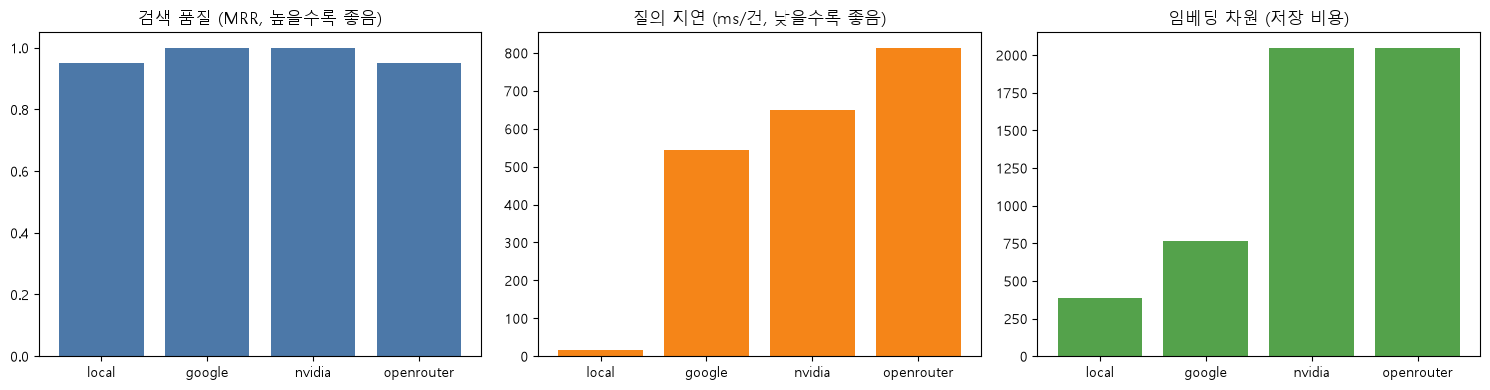

공급자별 실제 모델:
  local        paraphrase-multilingual-MiniLM-L12-v2
  google       gemini-embedding-001
  nvidia       nemotron-3-embed-1b
  openrouter   llama-nemotron-embed-vl-1b-v2:free


In [22]:
# 비교 결과 시각화 — 파일로 저장하지 않고 노트북에 바로 표시한다
try:
    import matplotlib.pyplot as plt

    emb.use_korean_font()  # OS 별 한글 폰트 설정(Windows: Malgun Gothic)

    ok_rows = [r for r in benchmark_rows if not r.error]
    if ok_rows:
        # X축 라벨은 공급자 약어만 쓴다 — 모델 전체 이름은 길어서 서로 겹친다
        names = [r.name.split(":")[0] for r in ok_rows]
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].bar(names, [r.mrr for r in ok_rows], color="#4C78A8")
        axes[0].set_title("검색 품질 (MRR, 높을수록 좋음)"); axes[0].set_ylim(0, 1.05)
        axes[1].bar(names, [r.query_sec * 1000 for r in ok_rows], color="#F58518")
        axes[1].set_title("질의 지연 (ms/건, 낮을수록 좋음)")
        axes[2].bar(names, [r.dim for r in ok_rows], color="#54A24B")
        axes[2].set_title("임베딩 차원 (저장 비용)")
        for ax in axes:
            ax.tick_params(axis="x", labelsize=10)
        plt.tight_layout()
        plt.show()

        print("공급자별 실제 모델:")
        for row in ok_rows:
            print(f"  {row.name.split(':')[0]:<12} {row.name.split(':', 1)[1]}")
except ImportError:
    print("matplotlib 미설치 — 표만 참고하세요 (uv pip install matplotlib)")

In [23]:
# 같은 질문에 대해 공급자별 Top-3 검색 결과가 어떻게 다른지 나란히 본다
probe_query = "모델이 없는 말을 지어내는 문제를 문서 검색으로 줄이는 방법은?"
gold_index = 4  # 정답: RAG 문서

print(f"질문: {probe_query}")
print(f"정답: [문서 {gold_index}] {emb.SAMPLE_CORPUS[gold_index]}\n")

for provider, embedder in embedders.items():
    try:
        doc_vecs = embedder.encode(emb.SAMPLE_CORPUS, kind="passage")
        query_vec = embedder.encode_one(probe_query, kind="query")
        print(f"[{embedder.name}]")
        for rank, (score, idx, text) in enumerate(
                emb.rank_by_similarity(query_vec, doc_vecs, emb.SAMPLE_CORPUS, top_k=3), 1):
            mark = "✅" if idx == gold_index else "  "
            print(f"  {mark} {rank}위 [{score:.3f}] 문서{idx}: {text[:44]}")
    except Exception as e:
        print(f"[{provider}] 실패: {str(e)[:100]}")
    print()

질문: 모델이 없는 말을 지어내는 문제를 문서 검색으로 줄이는 방법은?
정답: [문서 4] RAG는 검색으로 찾은 문서를 프롬프트에 넣어 환각을 줄이는 기법이다.

[local:paraphrase-multilingual-MiniLM-L12-v2]
  ✅ 1위 [0.546] 문서4: RAG는 검색으로 찾은 문서를 프롬프트에 넣어 환각을 줄이는 기법이다.
     2위 [0.297] 문서0: LangGraph는 상태 그래프로 에이전트 워크플로우를 구성하는 프레임워크다.
     3위 [0.285] 문서8: 벡터 임베딩은 문장의 의미를 고차원 실수 벡터로 바꿔 유사도 계산을 가능하게 한

[google:gemini-embedding-001]
  ✅ 1위 [0.746] 문서4: RAG는 검색으로 찾은 문서를 프롬프트에 넣어 환각을 줄이는 기법이다.
     2위 [0.603] 문서5: Ollama는 로컬 PC 에서 오픈 모델을 OpenAI 호환 API 로 서빙하는
     3위 [0.598] 문서8: 벡터 임베딩은 문장의 의미를 고차원 실수 벡터로 바꿔 유사도 계산을 가능하게 한

[nvidia:nemotron-3-embed-1b]
  ✅ 1위 [0.335] 문서4: RAG는 검색으로 찾은 문서를 프롬프트에 넣어 환각을 줄이는 기법이다.
     2위 [0.205] 문서8: 벡터 임베딩은 문장의 의미를 고차원 실수 벡터로 바꿔 유사도 계산을 가능하게 한
     3위 [0.174] 문서1: ChromaDB는 임베딩 벡터를 저장하고 유사도로 검색하는 오픈소스 벡터 데이터

[openrouter:llama-nemotron-embed-vl-1b-v2:free]
  ✅ 1위 [0.350] 문서4: RAG는 검색으로 찾은 문서를 프롬프트에 넣어 환각을 줄이는 기법이다.
     2위 [0.186] 문서8: 벡터 임베딩은 문장의 의미를 고차원 실수 벡터로 바꿔 유사도 계산을 가능하게 한
     3위 [0.177] 문서6: NeMo Guardrails는 Colang 규칙으로 대

### 4-1. 결과 해석 — 무엇을 골라야 하나

측정값은 실행 환경(네트워크·쿼터·모델 버전)에 따라 달라지지만, 경향은 대체로 이렇습니다.

| 상황 | 추천 | 이유 |
|---|---|---|
| 강의·실습·오프라인 데모 | **`local`** | 무료·무제한·수십 ms, 한국어 품질도 충분 |
| 품질이 최우선인 검색 | **`google`** | 큰 모델 + `taskType` 최적화, 차원 조절로 비용 타협 가능 |
| 한 키로 여러 모델 실험 | **`openrouter`** | `:free` 모델로 $0, 모델 id 만 바꿔 A/B 테스트 |
| GPU 추론 품질 + 무료 크레딧 | **`nvidia`** | 검색 특화 모델, `input_type` 으로 비대칭 인코딩 |

**실무 체크리스트**

1. **다국어 지원을 반드시 확인** — 영어 벤치마크 1위 모델이 한국어에서는 크게 무너집니다.
   (예: `nvidia/nv-embedqa-e5-v5` 는 영어 특화라 한국어 MRR 이 급락 → `nemotron-3-embed-1b` 사용)
2. **차원은 클수록 좋은 게 아니다** — 2048차원은 384차원보다 저장·검색 비용이 5배 이상입니다.
   Gemini 처럼 차원을 줄일 수 있으면(MRL) 768 정도가 비용/품질 균형점입니다.
3. **온라인은 지연이 지배적** — 표의 질의 시간을 보면 계산이 아니라 *네트워크 왕복* 이 대부분입니다.
   대량 색인은 배치로 묶고, 실시간 질의는 로컬 모델을 쓰는 하이브리드도 흔한 선택입니다.
4. **인덱스와 질의의 모델은 반드시 동일** — 공급자를 바꾸면 저장된 벡터를 전부 다시 만들어야 합니다.
5. **쿼터/과금 확인** — 무료 티어에는 분당 요청·토큰 제한이 있습니다. 실패 시 재시도·백오프가 필요합니다.

### 4-2. 최종 종합 — 의미 공간을 한 장으로 비교

지금까지의 표·숫자를 **한 장의 그림** 으로 모읍니다. 오프라인 2종 + 온라인 3종을
같은 문장 5개로 임베딩하고, 각 모델의 의미 공간을 나란히 놓습니다.

```
S0 오늘 날씨가 정말 좋다      ★ 기준 문장
S1 오늘 날씨 맑고 좋다        같은 뜻, 다른 단어  ┐
S2 비가 올 것 같은 날씨다      같은 주제(날씨), 다른 의미 ├ 날씨 그룹
S3 오늘 저녁은 치킨을 먹자     다른 주제(음식)     ┐
S4 맛있는 파스타 먹으러 가자   다른 주제(음식)     ┘ 음식 그룹
```

**그림 읽는 법**

| 요소 | 의미 |
|---|---|
| 화살표 | 원점에서 각 문장 벡터로 — PCA 로 2차원에 투영한 방향 |
| 점선 호 | 기준 문장(★)과 이루는 각도 — 좁을수록 의미가 가깝다 |
| 라벨의 % | **원래 고차원 공간**에서의 코사인 유사도(2D 각도가 아님) |
| 주제 분리도 | (같은 주제 쌍 평균) − (다른 주제 쌍 평균) 유사도. **클수록 좋음** |

> ⚠️ **PCA 는 정보를 잃습니다.** 768~2048차원을 2차원으로 눌렀기 때문에 화면상의 각도와
> 실제 코사인 유사도(%)가 어긋날 수 있습니다. 그림은 '직관'용이고, **판단은 % 와 분리도로** 합니다.
> (차원 축소는 `sklearn.decomposition.PCA(n_components=2)` 를 사용합니다.)

비교 대상 5종: ['local:paraphrase-multilingual-MiniLM-L12-v2', 'local:ko-sroberta-multitask', 'google:gemini-embedding-001', 'nvidia:nemotron-3-embed-1b', 'openrouter:llama-nemotron-embed-vl-1b-v2:free']



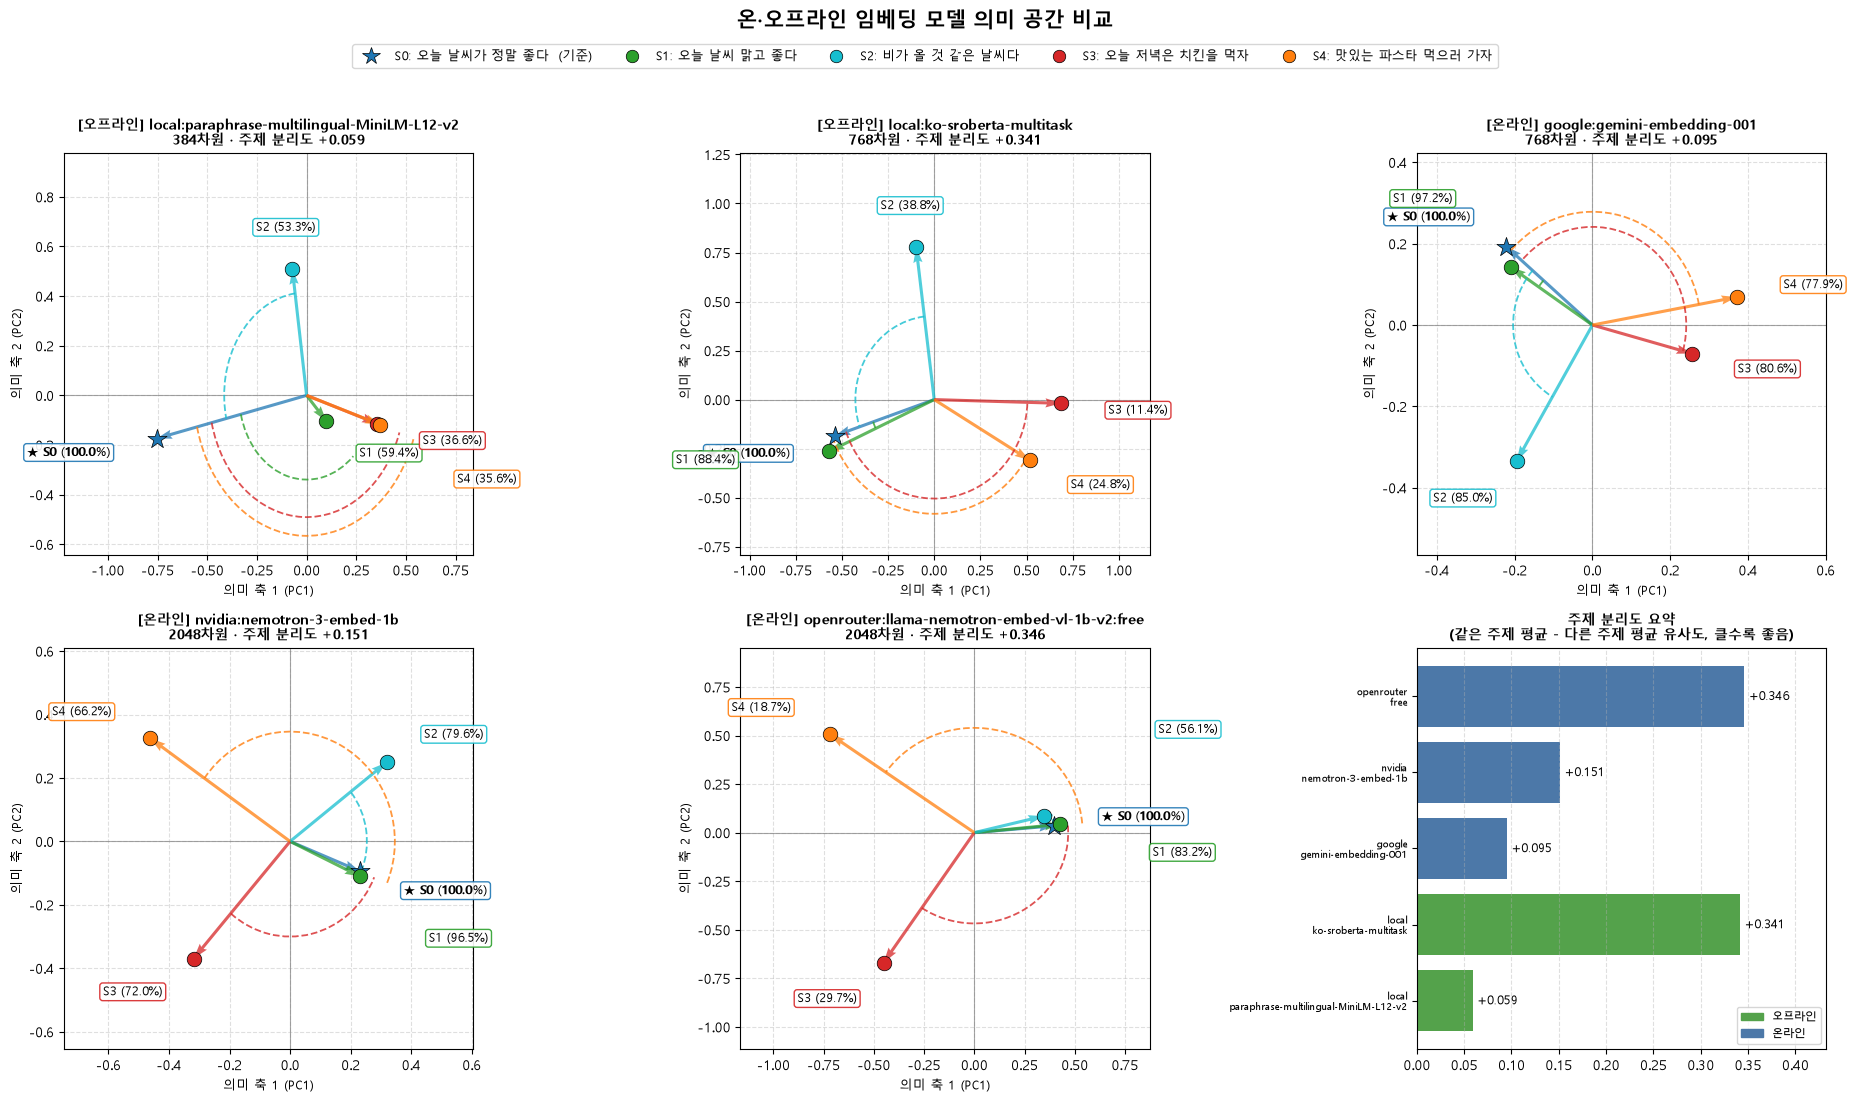


=== 주제 분리도 순위 (같은 주제 − 다른 주제 평균 유사도) ===
  1위  openrouter:llama-nemotron-embed-vl-1b-v2:free  +0.346
  2위  local:ko-sroberta-multitask                    +0.341
  3위  nvidia:nemotron-3-embed-1b                     +0.151
  4위  google:gemini-embedding-001                    +0.095
  5위  local:paraphrase-multilingual-MiniLM-L12-v2    +0.059


In [24]:
# 오프라인 2종 + 온라인 3종을 한 장의 그림으로 종합 비교
# (2-2 의 로컬 두 모델 + 3장의 온라인 공급자들)
viz_embedders = [local_embedder, local_ko] + [
    e for provider, e in embedders.items() if provider != "local"
]
print(f"비교 대상 {len(viz_embedders)}종: {[e.name for e in viz_embedders]}\n")

# save_path 를 주지 않으면 파일을 만들지 않고 노트북에 인라인으로만 그린다
separations = emb.plot_semantic_space(
    viz_embedders,
    sentences=emb.VIZ_SENTENCES,   # 날씨 3문장 + 음식 2문장
    groups=emb.VIZ_GROUPS,         # [0,0,0,1,1] — 같은 번호 = 같은 주제
)

print("\n=== 주제 분리도 순위 (같은 주제 − 다른 주제 평균 유사도) ===")
for rank, (name, value) in enumerate(sorted(separations.items(),
                                            key=lambda kv: -kv[1]), 1):
    print(f"  {rank}위  {name:<46} {value:+.3f}")

**이 그림에서 확인할 것**

1. **S0(★)와 S1 이 얼마나 붙어 있는가** — 같은 뜻을 다른 단어로 쓴 문장입니다.
   좋은 모델일수록 두 화살표가 거의 겹치고 유사도가 높습니다.
2. **날씨 3개(S0·S1·S2)와 음식 2개(S3·S4)가 갈라지는가** — 주제가 다르면 방향이 갈려야 합니다.
   주제 분리도가 낮은 모델은 무관한 문장에도 높은 점수를 줘서, 검색 시 오답을 섞어 옵니다.
3. **오프라인이 온라인보다 나쁘지 않다** — 한국어 특화 오프라인 모델이 대형 온라인 모델보다
   분리도가 높게 나오는 경우가 흔합니다. **비싸고 큰 모델 = 항상 좋음이 아닙니다.**
   내 데이터·내 언어로 재보는 것이 유일하게 믿을 수 있는 기준입니다.

---
## 6. 정리

### 배운 것

| 절 | 내용 | 핵심 API |
|---|---|---|
| 2 | 오프라인 임베딩 + 코사인 유사도, 로컬 모델 카탈로그·2종 비교 | `emb.get_embedder("local", model=...)`, `emb.print_local_catalog()`, `emb.list_hub_models()` |
| 3 | 온라인 무료 임베딩 3종(google/nvidia/openrouter) + 같은 문장 유사도 비교 | `emb.available_providers()`, `emb.get_embedder(provider)`, `emb.similarity_matrices()` |
| 4 | 오프라인 ↔ 온라인 성능 비교(속도·차원·MRR) + 의미 공간 종합 시각화 | `emb.benchmark()`, `emb.print_benchmark_table()`, `emb.plot_semantic_space()` |

### 기억할 원칙

1. **임베딩은 교체 가능한 부품** — `get_embedder(provider)` 한 줄로 바꾸고, **측정해서** 고른다.
2. **인덱스와 질의는 같은 모델로** — 공급자를 바꾸면 저장된 벡터를 전부 다시 만들어야 한다.
3. **비대칭 모델은 query/passage 를 구분** — 안 하면 검색 품질이 눈에 띄게 떨어진다.
4. **차원 축소 후에는 재정규화** — Gemini MRL 처럼 잘라낸 벡터는 단위벡터가 아니다.
5. **벡터 + 그래프** — 벡터는 "비슷한 것", 그래프는 "연결된 것"을 찾는다. 둘을 합치면 Graph RAG.
6. **모델은 크기가 아니라 적합도** — 한국어 특화 오프라인 모델이 대형 온라인 모델을 이기기도 한다.
   반드시 **내 언어·내 데이터** 로 재보고 고른다.

### 다음 편

- [`M04_2_vector_rag.ipynb`](M04_2_vector_rag.ipynb) — ChromaDB 로 본격적인 Vector RAG 구축
- [`M04_3_graph_rag.ipynb`](M04_3_graph_rag.ipynb) — 지식 그래프 · Neo4j · Hybrid RAG
- [`M04_4_agent_memory.ipynb`](M04_4_agent_memory.ipynb) — 에이전트 메모리를 직접 구현해 RAG 와 결합
- [`M04_5_memory.ipynb`](M04_5_memory.ipynb) — 같은 메모리를 LangGraph 표준 부품으로(체크포인터 · Store · 영속화)